                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

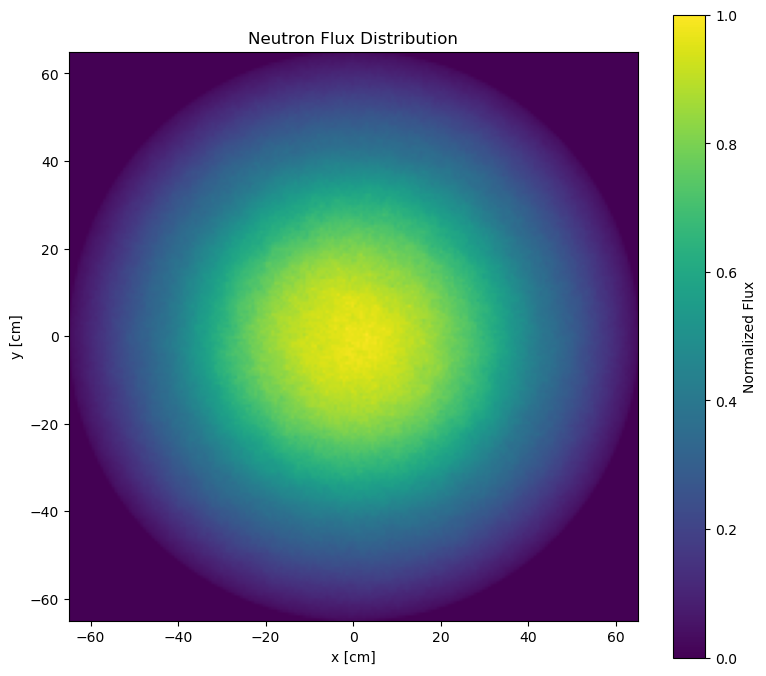

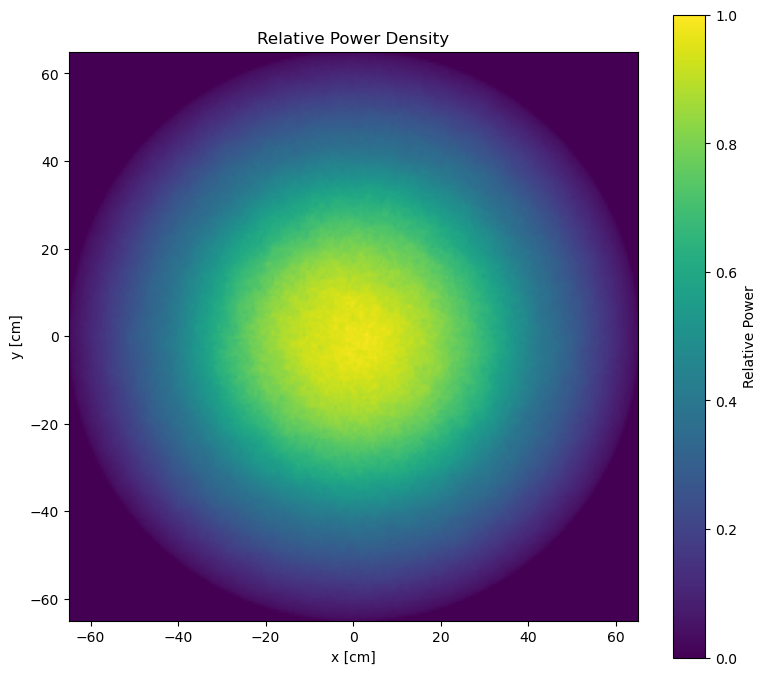

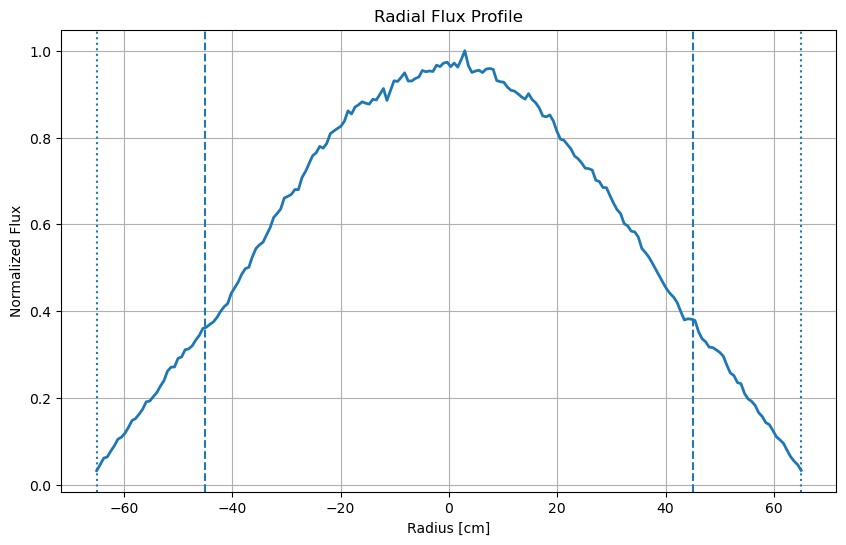

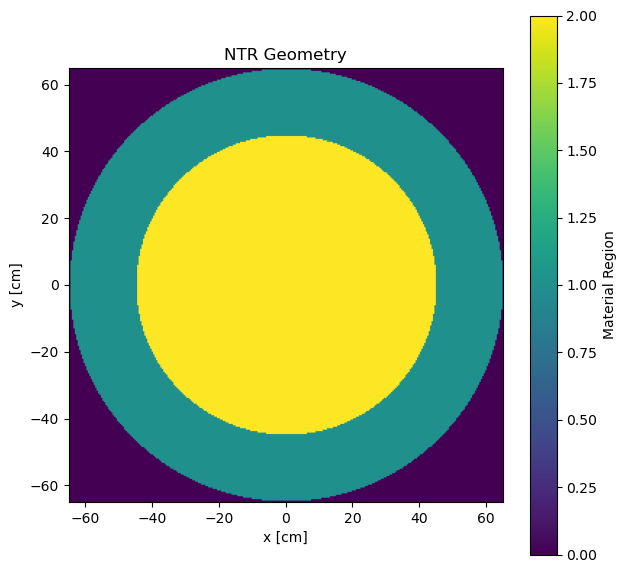

In [6]:
# ============================================================
# NUCLEAR THERMAL ROCKET (NTR)
# OPENMC MONTE CARLO CRITICALITY ANALYSIS
# ============================================================
#
# Author : Clésio Ismério de Oliveira
#
# Description:
#
# Simplified Nuclear Thermal Rocket reactor using
# continuous-energy neutron transport with OpenMC.
#
# Features:
#
# - Monte Carlo neutron transport
# - k-effective calculation
# - Fuel region
# - Graphite reflector
# - Vacuum boundary conditions
# - Flux mesh tally
# - Relative power map
# - Geometry visualization
#
# ============================================================

import os
import openmc
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# NUCLEAR DATA
# ============================================================

# Adjust to your installation

os.environ["OPENMC_CROSS_SECTIONS"] = \
"/home/clesio/openmcData/cross_sections.xml"

# ============================================================
# MATERIALS
# ============================================================

fuel = openmc.Material(name='UO2 Fuel')

fuel.add_nuclide('U235', 0.1975)
fuel.add_nuclide('U238', 0.8025)

fuel.add_element('O', 2.0)

fuel.set_density('g/cm3', 10.5)

# ------------------------------------------------------------

graphite = openmc.Material(name='Graphite Reflector')

graphite.add_element('C', 1.0)

graphite.set_density('g/cm3', 1.8)

# ------------------------------------------------------------

materials = openmc.Materials(
    [
        fuel,
        graphite
    ]
)

materials.export_to_xml()

# ============================================================
# GEOMETRY
# ============================================================

core_radius = 45.0
reflector_radius = 65.0

height = 100.0

# ------------------------------------------------------------
# Cylinders
# ------------------------------------------------------------

core = openmc.ZCylinder(
    r=core_radius
)

outer_boundary = openmc.ZCylinder(
    r=reflector_radius,
    boundary_type='vacuum'
)

# ------------------------------------------------------------
# Axial boundaries
# ------------------------------------------------------------

zmin = openmc.ZPlane(
    z0=-height/2,
    boundary_type='vacuum'
)

zmax = openmc.ZPlane(
    z0=height/2,
    boundary_type='vacuum'
)

# ------------------------------------------------------------
# Regions
# ------------------------------------------------------------

fuel_region = (
    -core &
    +zmin &
    -zmax
)

reflector_region = (
    +core &
    -outer_boundary &
    +zmin &
    -zmax
)

# ------------------------------------------------------------
# Cells
# ------------------------------------------------------------

fuel_cell = openmc.Cell(
    name='Fuel',
    fill=fuel,
    region=fuel_region
)

reflector_cell = openmc.Cell(
    name='Reflector',
    fill=graphite,
    region=reflector_region
)

# ------------------------------------------------------------
# Universe
# ------------------------------------------------------------

universe = openmc.Universe(
    cells=[
        fuel_cell,
        reflector_cell
    ]
)

geometry = openmc.Geometry(
    universe
)

geometry.export_to_xml()

# ============================================================
# GEOMETRY PLOT
# ============================================================

plot = openmc.Plot()

plot.filename = 'geometry'

plot.width = (
    2*reflector_radius,
    2*reflector_radius
)

plot.pixels = (
    800,
    800
)

plot.color_by = 'material'

plots = openmc.Plots([plot])

plots.export_to_xml()

openmc.plot_geometry()

# ============================================================
# SOURCE
# ============================================================

source = openmc.IndependentSource()

source.space = openmc.stats.CylindricalIndependent(
    r=openmc.stats.Uniform(
        0.0,
        core_radius
    ),
    phi=openmc.stats.Uniform(
        0.0,
        2*np.pi
    ),
    z=openmc.stats.Uniform(
        -height/2,
        height/2
    )
)

# ============================================================
# SETTINGS
# ============================================================

settings = openmc.Settings()

settings.run_mode = 'eigenvalue'

settings.batches = 120

settings.inactive = 30

settings.particles = 20000

settings.source = source

settings.export_to_xml()

# ============================================================
# MESH TALLY
# ============================================================

mesh = openmc.RegularMesh()

mesh.dimension = (
    200,
    200
)

mesh.lower_left = (
    -reflector_radius,
    -reflector_radius
)

mesh.upper_right = (
    reflector_radius,
    reflector_radius
)

mesh_filter = openmc.MeshFilter(mesh)

# ------------------------------------------------------------

flux_tally = openmc.Tally(
    name='flux'
)

flux_tally.filters = [
    mesh_filter
]

flux_tally.scores = [
    'flux'
]

# ------------------------------------------------------------

tallies = openmc.Tallies(
    [flux_tally]
)

tallies.export_to_xml()

# ============================================================
# RUN OPENMC
# ============================================================

openmc.run()

# ============================================================
# LOAD RESULTS
# ============================================================

sp = openmc.StatePoint(
    'statepoint.120.h5'
)

print("\n================================")
print("OPENMC RESULTS")
print("================================")
print(f"k-effective = {sp.keff}")

# ============================================================
# FLUX TALLY
# ============================================================

tally = sp.get_tally(
    name='flux'
)

flux = tally.mean.ravel()

flux = flux.reshape(
    mesh.dimension
)

flux /= flux.max()

# ============================================================
# FLUX MAP
# ============================================================

plt.figure(figsize=(8,7))

plt.imshow(
    flux,
    origin='lower',
    extent=[
        -reflector_radius,
        reflector_radius,
        -reflector_radius,
        reflector_radius
    ]
)

plt.colorbar(
    label='Normalized Flux'
)

plt.xlabel('x [cm]')
plt.ylabel('y [cm]')

plt.title(
    'Neutron Flux Distribution'
)

plt.tight_layout()

plt.show()

# ============================================================
# POWER MAP
# ============================================================

power_density = flux.copy()

plt.figure(figsize=(8,7))

plt.imshow(
    power_density,
    origin='lower',
    extent=[
        -reflector_radius,
        reflector_radius,
        -reflector_radius,
        reflector_radius
    ]
)

plt.colorbar(
    label='Relative Power'
)

plt.xlabel('x [cm]')
plt.ylabel('y [cm]')

plt.title(
    'Relative Power Density'
)

plt.tight_layout()

plt.show()

# ============================================================
# RADIAL PROFILE
# ============================================================

centerline = flux[
    mesh.dimension[0]//2,
    :
]

x = np.linspace(
    -reflector_radius,
    reflector_radius,
    mesh.dimension[1]
)

plt.figure(figsize=(10,6))

plt.plot(
    x,
    centerline,
    linewidth=2
)

plt.axvline(
    -core_radius,
    linestyle='--'
)

plt.axvline(
    core_radius,
    linestyle='--'
)

plt.axvline(
    -reflector_radius,
    linestyle=':'
)

plt.axvline(
    reflector_radius,
    linestyle=':'
)

plt.grid(True)

plt.xlabel('Radius [cm]')
plt.ylabel('Normalized Flux')

plt.title(
    'Radial Flux Profile'
)

plt.show()

# ============================================================
# REACTOR MAP
# ============================================================

xg = np.linspace(
    -reflector_radius,
    reflector_radius,
    300
)

yg = np.linspace(
    -reflector_radius,
    reflector_radius,
    300
)

X,Y = np.meshgrid(
    xg,
    yg
)

R = np.sqrt(
    X**2 + Y**2
)

material_map = np.zeros_like(R)

material_map[
    R < core_radius
] = 2

material_map[
    (R >= core_radius)
    &
    (R < reflector_radius)
] = 1

plt.figure(figsize=(7,7))

plt.imshow(
    material_map,
    origin='lower',
    extent=[
        -reflector_radius,
        reflector_radius,
        -reflector_radius,
        reflector_radius
    ]
)

plt.colorbar(
    label='Material Region'
)

plt.xlabel('x [cm]')
plt.ylabel('y [cm]')

plt.title(
    'NTR Geometry'
)

plt.show()

# ============================================================
# END
# ============================================================